## Universidad Autónoma de Aguascalientes
## Departamento: Ciencias de la Computación
## Carrera: Ingeniería en Computación Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864)
## Semestre: Enero - Junio del 2026

---
# Fase 3: Síntesis de Rostros mediante Red Generativa Adversaria (GAN)

## Descripción del Proyecto

Este proyecto implementa una **Red Generativa Adversaria (GAN)** cuyo único objetivo es aprender a **sintetizar imágenes realistas del rostro del autor** a partir de un dataset capturado con webcam.

A diferencia de la Fase 2 (clasificación de emociones), aquí **no hay etiquetas ni categorías**. La tarea es que el Generador aprenda la distribución de píxeles de un rostro real y produzca imágenes nuevas indistinguibles de las originales.

---
## Arquitectura GAN (Fig. 1 — referencia del curso)

```
  ① dato real ──────────────────────────────────────────────────────┐
                                                                      ▼
  ② Ruido  ──►  GENERADOR  ──►  ③ dato fake  ──►  DISCRIMINADOR  ──►  ¿real / fake?
                   ▲                                      │
                   │                           ┌──────────┴──────────┐
                   │                      ⑤ Loss_D              ⑥ Loss_G
                   │                    (ajusta D)             (ajusta G)
                   └───────────────────────────┘
```

| Componente | Rol | Señal de ajuste |
|---|---|---|
| **Generador (G)** | Convierte ruido gaussiano en imagen de rostro | `Loss_G` — quiere engañar a D |
| **Discriminador (D)** | Decide si una imagen es real o sintética | `Loss_D` — quiere no ser engañado |

---
## Indicadores de éxito

| Indicador | Método | Meta |
|---|---|---|
| Mejora visual | Mosaico de imágenes generadas por época | Rostro reconocible y nítido |
| Curvas de pérdida | Gráficas `Loss_D` vs `Loss_G` | Convergencia, no colapso |
| Confianza D | `D(x)` y `D(G(z))` | Ambos → 0.5 (equilibrio) |
| Diversidad | Varianza entre imágenes generadas | Alta → sin mode collapse |

### Paso 1: Importar liberías y preparar el environment

In [1]:
import os
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, utils

# Configuración de dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Trabajando en: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

    
DATASET_DIR    = Path('dataset_rostros_pt')  
IMG_SIZE   = 64    

Trabajando en: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## Paso 2: Crear dataset o reutilizar uno existente:

═══════════════════════════════════════════════════════
  DATASET EXISTENTE
═══════════════════════════════════════════════════════
  Carpeta           : dataset_rostros_pt
  Imágenes halladas : 642
  Último índice     : img_722.jpg
  Próxima captura   : img_723.jpg
═══════════════════════════════════════════════════════

🎥  Cámara abierta. Meta de fotos adicionales: 5000
   ESPACIO=capturar  │  Q=terminar
  ⏹  Sesión terminada. Fotos nuevas: 0

═══════════════════════════════════════════════════════
  DATASET TOTAL  : 642 imágenes
  Fotos nuevas   : 0
  Rango de índices: img_0 … img_722
═══════════════════════════════════════════════════════


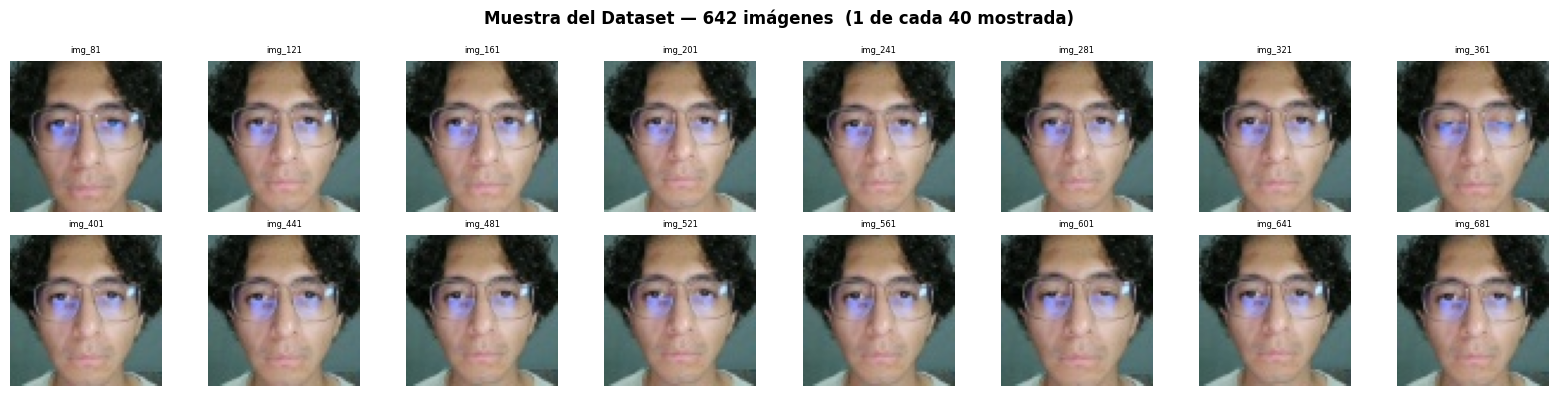

Mosaico guardado como muestra_dataset_crudo.png


In [2]:

# ── Utilidad: ordenar img_N numéricamente ─────────────────────────────
def _indice(p):
    """Extrae el entero N de un Path cuyo stem es 'img_N'."""
    try:
        return int(p.stem.split('_')[1])
    except (IndexError, ValueError):
        return -1

# ── Detectar el siguiente índice libre ────────────────────────────────
imgs_existentes = [p for p in DATASET_DIR.iterdir()
                   if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
                   and p.stem.startswith('img_')]
siguiente_idx = max((_indice(p) for p in imgs_existentes), default=-1) + 1

print('═' * 55)
print('  DATASET EXISTENTE')
print('═' * 55)
print(f'  Carpeta           : {DATASET_DIR}')
print(f'  Imágenes halladas : {len(imgs_existentes)}')
print(f'  Último índice     : img_{siguiente_idx - 1}.jpg')
print(f'  Próxima captura   : img_{siguiente_idx}.jpg')
print('═' * 55)

# ── Sesión de captura ─────────────────────────────────────────────────
META_ADICIONALES = 5000   # Cuántas fotos más quieres tomar (0 = solo revisar)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

contador       = siguiente_idx
nuevas         = 0
ultima_captura = 0

# Variables para el suavizado exponencial (memoria del frame anterior)
prev_x, prev_y, prev_w, prev_h = 0, 0, 0, 0
alpha = 0.25  # Factor de suavizado: 1.0 = sin suavizado (volátil), 0.1 = muy suave (con retraso)

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print('\n⚠  Cámara no disponible — se omite la captura.')
    print('   El dataset existente se usará tal cual.')
else:
    print(f'\n🎥  Cámara abierta. Meta de fotos adicionales: {META_ADICIONALES}')
    print('   ESPACIO=capturar  │  Q=terminar')

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray_eq = cv2.equalizeHist(gray)
        faces   = face_cascade.detectMultiScale(
            gray_eq, scaleFactor=1.15, minNeighbors=6, minSize=(80, 80))

        display     = frame.copy()
        rostro_crop = None

        for (det_x, det_y, det_w, det_h) in faces:
            # 1. Aplicar Suavizado Exponencial (EMA)
            if prev_w == 0:  # Primer frame con detección
                x, y, w, h = det_x, det_y, det_w, det_h
            else:
                x = int(alpha * det_x + (1 - alpha) * prev_x)
                y = int(alpha * det_y + (1 - alpha) * prev_y)
                w = int(alpha * det_w + (1 - alpha) * prev_w)
                h = int(alpha * det_h + (1 - alpha) * prev_h)

            # Actualizar la memoria
            prev_x, prev_y, prev_w, prev_h = x, y, w, h

            # 2. Forzar una caja de recorte perfectamente cuadrada
            cx = x + w // 2
            cy = y + h // 2
            
            # Usamos el lado más grande detectado + un 20% de margen total (10% por lado)
            lado = int(max(w, h) * 1.20) 
            mitad_lado = lado // 2

            x1 = cx - mitad_lado
            y1 = cy - mitad_lado
            x2 = cx + mitad_lado
            y2 = cy + mitad_lado

            # Validar que el cuadrado no se salga de los límites del frame
            # Si se sale, ajustamos las coordenadas pero MANTENIENDO la forma cuadrada
            if x1 < 0:
                x2 -= x1; x1 = 0
            if y1 < 0:
                y2 -= y1; y1 = 0
            if x2 > frame.shape[1]:
                x1 -= (x2 - frame.shape[1]); x2 = frame.shape[1]
            if y2 > frame.shape[0]:
                y1 -= (y2 - frame.shape[0]); y2 = frame.shape[0]
            
            # Evitar errores si el rostro está demasiado pegado a una esquina y el recorte falla
            x1, y1 = max(0, x1), max(0, y1)
            
            # Dibujar recuadro estabilizado
            cv2.rectangle(display, (x1, y1), (x2, y2), (0, 230, 100), 2)
            
            crop_color = frame[y1:y2, x1:x2]
            
            # Asegurarse de que el recorte tenga un tamaño válido antes de redimensionar
            if crop_color.shape[0] > 0 and crop_color.shape[1] > 0:
                rostro_crop = cv2.resize(crop_color, (IMG_SIZE, IMG_SIZE),
                                         interpolation=cv2.INTER_AREA)
            break # Solo procesamos el primer rostro detectado

        # Si en algún frame se pierde el rostro, reseteamos la memoria del suavizado
        if len(faces) == 0:
            prev_w = 0 

        # ── HUD ──────────────────────────────────────────────────────
        estado    = '✓ Rostro detectado' if rostro_crop is not None else '— Sin rostro'
        color_hud = (0, 230, 100) if rostro_crop is not None else (0, 80, 220)
        pct       = min(100, int(nuevas / max(META_ADICIONALES, 1) * 100))
        barra     = '█' * (pct // 4) + '░' * (25 - pct // 4)

        cv2.putText(display, estado,
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color_hud, 2)
        cv2.putText(display, f'Nueva: img_{contador}.jpg  [{nuevas}/{META_ADICIONALES}]',
                    (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.60, (255, 255, 255), 2)
        cv2.putText(display, f'[{barra}] {pct}%',
                    (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (200, 200, 200), 1)
        cv2.putText(display, 'ESPACIO=capturar  Q=salir',
                    (10, display.shape[0] - 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (180, 180, 180), 1)

        if rostro_crop is not None:
            mini = cv2.resize(rostro_crop, (80, 80))   # ya es BGR
            display[10:90, display.shape[1]-90:display.shape[1]-10] = mini

        cv2.imshow('GAN — Ampliar Dataset', display)
        tecla = cv2.waitKey(1) & 0xFF
        ahora = time.time()

        if tecla == ord(' ') and rostro_crop is not None and (ahora - ultima_captura) > 0.3:
            ruta_img = DATASET_DIR / f'img_{contador}.jpg'
            cv2.imwrite(str(ruta_img), rostro_crop)
            contador       += 1
            nuevas         += 1
            ultima_captura  = ahora
            if nuevas % 25 == 0:
                print(f'  📷  {nuevas}/{META_ADICIONALES} fotos nuevas guardadas.')
            if nuevas >= META_ADICIONALES:
                print(f'  ✅  Meta de {META_ADICIONALES} fotos adicionales alcanzada.')
                break

        elif tecla == ord('q') or tecla == 27:
            print(f'  ⏹  Sesión terminada. Fotos nuevas: {nuevas}')
            break

    cap.release()
    cv2.destroyAllWindows()

# ── Resumen y mosaico del dataset completo ────────────────────────────
todas_las_fotos = sorted(
    [p for p in DATASET_DIR.iterdir()
     if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
     and p.stem.startswith('img_')],
    key=_indice
)

print()
print('═' * 55)
print(f'  DATASET TOTAL  : {len(todas_las_fotos)} imágenes')
print(f'  Fotos nuevas   : {nuevas}')
print(f'  Rango de índices: img_0 … img_{_indice(todas_las_fotos[-1])}')
print('═' * 55)

# Mosaico espaciado uniformemente (16 muestras representativas)
paso         = max(1, len(todas_las_fotos) // 16)
muestra_paths = todas_las_fotos[::paso][:16]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle(f'Muestra del Dataset — {len(todas_las_fotos)} imágenes  '
             f'(1 de cada {paso} mostrada)',
             fontsize=12, fontweight='bold')
for ax, p in zip(axes.flat, muestra_paths):
    img = cv2.imread(str(p))
    if img is None:
        ax.axis('off'); continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR→RGB para matplotlib
    ax.imshow(img)
    ax.set_title(p.stem, fontsize=6)
    ax.axis('off')
for ax in axes.flat[len(muestra_paths):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('muestra_dataset_crudo.png', dpi=110, bbox_inches='tight')
plt.show()
print('Mosaico guardado como muestra_dataset_crudo.png')

### Paso 3: Mostramos una cuadrícula con ejemplos del dataset

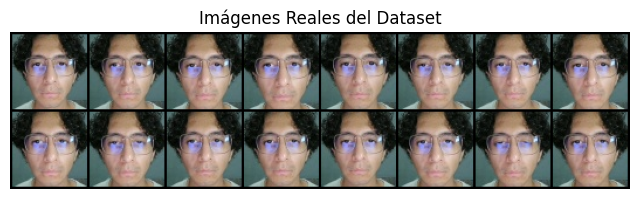

In [3]:
class FaceDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.images = [f for f in os.listdir(folder) if f.endswith('.jpg')]
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.folder, self.images[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform: image = self.transform(image)
        return image

# Transformaciones estándar para GANs: Normalizar a [-1, 1]
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = FaceDataset(DATASET_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Visualización de verificación
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Imágenes Reales del Dataset")
plt.imshow(np.transpose(utils.make_grid(real_batch[:16], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

### Paso 5: Definición de la Arquitectura DCGANEn esta celda se definen los "cerebros" del proyecto. 
Una GAN (Generative Adversarial Network) consiste en dos redes neuronales que compiten entre sí:
- El Generador ($G$): Su misión es crear imágenes realistas a partir de un vector de ruido aleatorio ($z$). Utiliza capas de convolución transpuesta para transformar un vector de 100 dimensiones en una imagen de 64x64 píxeles.
- El Discriminador ($D$): Actúa como un crítico de arte o un detective. Su trabajo es clasificar si una imagen es "Real" (del dataset) o "Falsa" (creada por $G$).

**Detalles clave:**

- Spectral Normalization: Aplicada en el Discriminador para estabilizar el entrenamiento y evitar que la red se vuelva demasiado "estricta" muy rápido.
- Activaciones: Usamos ReLU en el Generador para permitir el flujo de gradientes y LeakyReLU en el Discriminador para evitar neuronas "muertas".
- Salida Tanh: El Generador escala los píxeles entre -1 y 1 para una convergencia más rápida.

In [4]:
# Hiperparámetros de arquitectura
nz = 100  # Tamaño del vector de ruido
ngf = 64  # Tamaño de feature maps en generador
ndf = 64  # Tamaño de feature maps en discriminador


class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Entrada es el ruido Z, yendo a una convolución transpuesta
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # (ngf) x 32 x 32
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
            # Salida: 3 x 64 x 64
        )

    def forward(self, input):
        return self.main(input)

from torch.nn.utils import spectral_norm

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Capa de entrada: Aplicamos spectral_norm a la convolución
            spectral_norm(nn.Conv2d(3, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            # Bloque 2
            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # Bloque 3
            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # Bloque 4
            spectral_norm(nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # Capa de salida
            spectral_norm(nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False)),
            nn.Sigmoid(),
        )

    def forward(self, input):
        return self.main(input)


# Inicialización de pesos recomendada por el paper de DCGAN
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


netG = Generator().to(device)
netG.apply(weights_init)
netD = Discriminator().to(device)
netD.apply(weights_init)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

### Paso 6: El Bucle de Entrenamiento AdversarioAquí es donde ocurre la competencia. 

El entrenamiento se divide en dos fases por cada lote de imágenes:
1. Fase del Discriminador: Se le muestran fotos reales y fotos falsas. Aprende a distinguir las diferencias calculando el error (BCELoss) y ajustando sus pesos.
2. Fase del Generador: $G$ crea nuevas imágenes, se las pasa a $D$, y si $D$ las detecta como falsas, $G$ recibe una "penalización" (gradiente). $G$ ajusta sus pesos para que en la siguiente ronda $D$ crea que sus fotos son reales.

**Métricas de control:D(x):** 

- Confianza de la red en las fotos reales.
- D(G(z)): Qué tan bien está engañando el generador al crítico. El objetivo es que ambos lleguen a 0.5, indicando que el generador es tan bueno que el discriminador ya no puede distinguir la verdad de la ficción.

Iniciando Entrenamiento...
Época [0/250]
  ├─ Loss D: 1.3020 | Loss G: 3.6981
  ├─ D(x): 0.3955 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.3092 (Ideal: ~0.5) -> Capacidad de Engaño


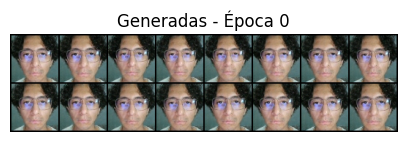

Época [10/250]
  ├─ Loss D: 0.7507 | Loss G: 3.2499
  ├─ D(x): 0.5397 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0386 (Ideal: ~0.5) -> Capacidad de Engaño


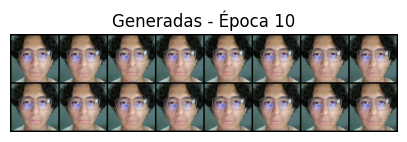

Época [20/250]
  ├─ Loss D: 0.0638 | Loss G: 5.2053
  ├─ D(x): 0.9967 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0581 (Ideal: ~0.5) -> Capacidad de Engaño


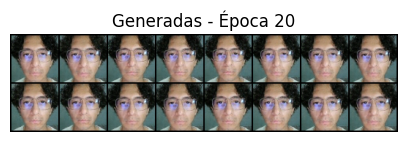

Época [30/250]
  ├─ Loss D: 1.6967 | Loss G: 19.1805
  ├─ D(x): 0.9867 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.8136 (Ideal: ~0.5) -> Capacidad de Engaño


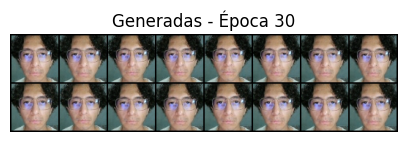

Época [40/250]
  ├─ Loss D: 0.6632 | Loss G: 10.0346
  ├─ D(x): 0.8470 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.3649 (Ideal: ~0.5) -> Capacidad de Engaño


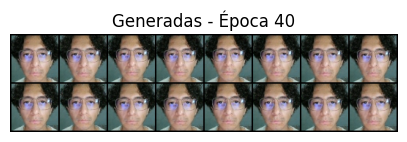

Época [50/250]
  ├─ Loss D: 0.7593 | Loss G: 1.1834
  ├─ D(x): 0.5794 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.1477 (Ideal: ~0.5) -> Capacidad de Engaño


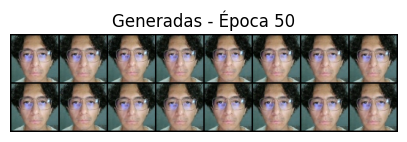

Época [60/250]
  ├─ Loss D: 0.2412 | Loss G: 4.6041
  ├─ D(x): 0.8860 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.1088 (Ideal: ~0.5) -> Capacidad de Engaño


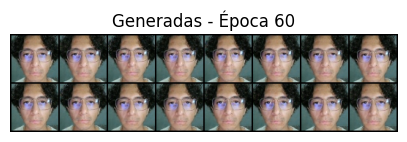

Época [70/250]
  ├─ Loss D: 0.4794 | Loss G: 5.3105
  ├─ D(x): 0.7537 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.1284 (Ideal: ~0.5) -> Capacidad de Engaño


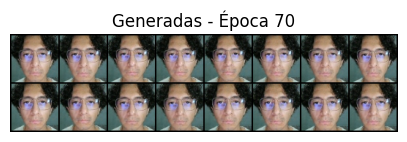

Época [80/250]
  ├─ Loss D: 0.7323 | Loss G: 1.9300
  ├─ D(x): 0.6229 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.1054 (Ideal: ~0.5) -> Capacidad de Engaño


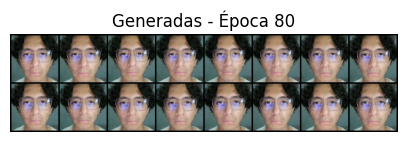

Época [90/250]
  ├─ Loss D: 0.1004 | Loss G: 4.8924
  ├─ D(x): 0.9166 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0124 (Ideal: ~0.5) -> Capacidad de Engaño


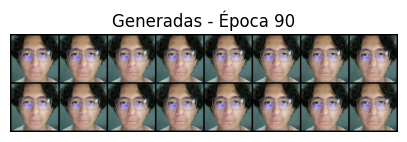

Época [100/250]
  ├─ Loss D: 0.0601 | Loss G: 5.0276
  ├─ D(x): 0.9887 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0475 (Ideal: ~0.5) -> Capacidad de Engaño


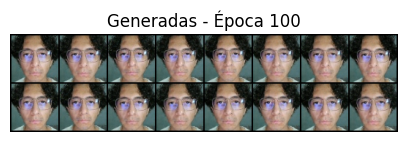

Época [110/250]
  ├─ Loss D: 0.0639 | Loss G: 5.4882
  ├─ D(x): 0.9646 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0268 (Ideal: ~0.5) -> Capacidad de Engaño


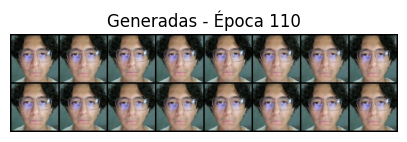

Época [120/250]
  ├─ Loss D: 1.0134 | Loss G: 2.9680
  ├─ D(x): 0.4234 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.1265 (Ideal: ~0.5) -> Capacidad de Engaño


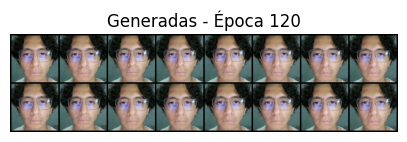

Época [130/250]
  ├─ Loss D: 0.3814 | Loss G: 8.7536
  ├─ D(x): 0.9970 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.2808 (Ideal: ~0.5) -> Capacidad de Engaño


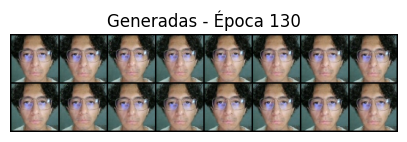

Época [140/250]
  ├─ Loss D: 0.4995 | Loss G: 3.0964
  ├─ D(x): 0.7198 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.1377 (Ideal: ~0.5) -> Capacidad de Engaño


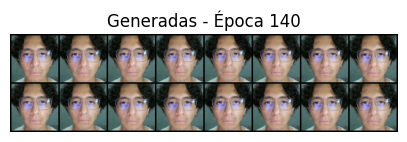

Época [150/250]
  ├─ Loss D: 0.8415 | Loss G: 15.5532
  ├─ D(x): 0.9775 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.4344 (Ideal: ~0.5) -> Capacidad de Engaño
  ★ ¡ESTADO ÓPTIMO!: El generador está logrando engañar al discriminador.


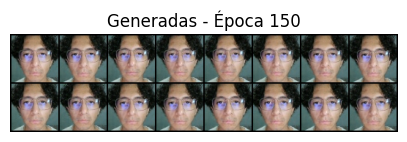

Época [160/250]
  ├─ Loss D: 0.0222 | Loss G: 5.9091
  ├─ D(x): 0.9833 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0052 (Ideal: ~0.5) -> Capacidad de Engaño


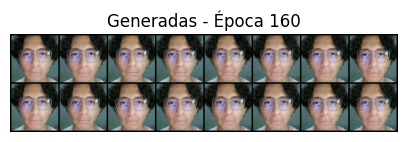

Época [170/250]
  ├─ Loss D: 0.2883 | Loss G: 7.1387
  ├─ D(x): 0.7826 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0030 (Ideal: ~0.5) -> Capacidad de Engaño


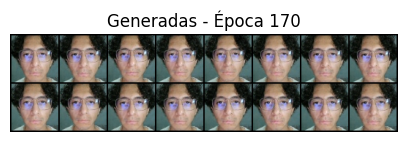

Época [180/250]
  ├─ Loss D: 0.2077 | Loss G: 7.9452
  ├─ D(x): 0.8303 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0004 (Ideal: ~0.5) -> Capacidad de Engaño


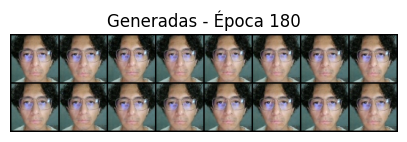

Época [190/250]
  ├─ Loss D: 0.7345 | Loss G: 6.1769
  ├─ D(x): 0.6705 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.1692 (Ideal: ~0.5) -> Capacidad de Engaño


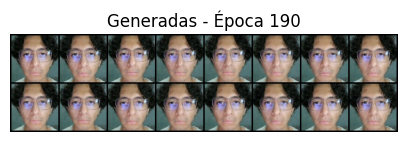

Época [200/250]
  ├─ Loss D: 0.0466 | Loss G: 7.0156
  ├─ D(x): 0.9562 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0017 (Ideal: ~0.5) -> Capacidad de Engaño


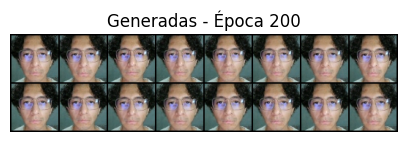

Época [210/250]
  ├─ Loss D: 0.1646 | Loss G: 3.5212
  ├─ D(x): 0.8956 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 0.0522 (Ideal: ~0.5) -> Capacidad de Engaño


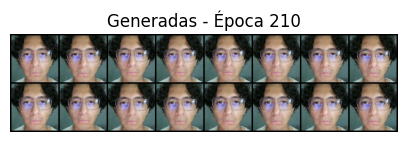

Época [220/250]
  ├─ Loss D: 100.0000 | Loss G: 0.0000
  ├─ D(x): 1.0000 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 1.0000 (Ideal: ~0.5) -> Capacidad de Engaño


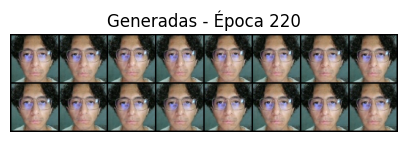

Época [230/250]
  ├─ Loss D: 100.0000 | Loss G: 0.0000
  ├─ D(x): 1.0000 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 1.0000 (Ideal: ~0.5) -> Capacidad de Engaño


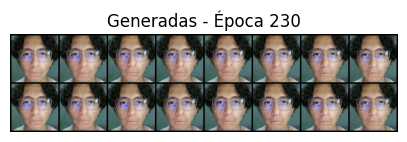

Época [240/250]
  ├─ Loss D: 100.0000 | Loss G: 0.0000
  ├─ D(x): 1.0000 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 1.0000 (Ideal: ~0.5) -> Capacidad de Engaño


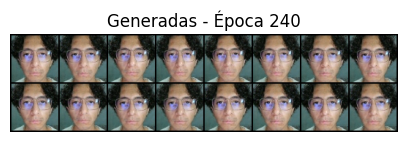

Época [249/250]
  ├─ Loss D: 100.0000 | Loss G: 0.0000
  ├─ D(x): 1.0000 (Ideal: ~0.5 a 0.9) -> Confianza en Reales
  └─ D(G(z)): 1.0000 (Ideal: ~0.5) -> Capacidad de Engaño


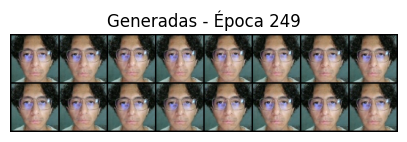

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
#  CELDA DE ENTRENAMIENTO — COMPETENCIA ADVERSARIA
# ═══════════════════════════════════════════════════════════════════════

criterion = nn.BCELoss()
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

history = {
    'd_loss': [],
    'g_loss': [],
    'd_x': [],
    'd_gz': []
}
evolucion_imagenes = []

num_epochs = 500
print("Iniciando Entrenamiento...")

for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):
        # -----------------------------------------------------------
        # (1) Actualizar Discriminador: maximizar log(D(x)) + log(1 - D(G(z)))
        # -----------------------------------------------------------
        netD.zero_grad()
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), 1.0, dtype=torch.float, device=device)
        
        output_real = netD(real_cpu).view(-1)
        errD_real = criterion(output_real, label)
        errD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.0)
        output_fake = netD(fake.detach()).view(-1)
        errD_fake = criterion(output_fake, label)
        errD_fake.backward()
        optimizerD.step()

        # -----------------------------------------------------------
        # (2) Actualizar Generador: maximizar log(D(G(z)))
        # -----------------------------------------------------------
        netG.zero_grad()
        label.fill_(1.0) 
        output_gen = netD(fake).view(-1)
        errG = criterion(output_gen, label)
        errG.backward()
        optimizerG.step()

    # Registro de métricas por época
    history['d_loss'].append(errD_real.item() + errD_fake.item())
    history['g_loss'].append(errG.item())
    history['d_x'].append(output_real.mean().item())
    history['d_gz'].append(output_fake.mean().item())
    
    # Captura de evolución visual
    if epoch % 50 == 0 or epoch == num_epochs - 1:
        with torch.no_grad():
            netG.eval()
            muestra = netG(fixed_noise)[0].detach().cpu()
            evolucion_imagenes.append((epoch, muestra))
            netG.train()

    # Monitoreo de consola
    if epoch % 10 == 0 or epoch == num_epochs - 1:
        D_x = output_real.mean().item() 
        D_G_z = output_fake.mean().item()
        
        print(f'Época [{epoch}/{num_epochs}]')
        print(f'  ├─ Loss D: {errD_real.item()+errD_fake.item():.4f} | Loss G: {errG.item():.4f}')
        print(f'  ├─ D(x): {D_x:.4f} | D(G(z)): {D_G_z:.4f}')
        
        if 0.4 <= D_G_z <= 0.6:
            print("  ★ ¡ESTADO ÓPTIMO!")
            
        with torch.no_grad():
            netG.eval()
            fake_display = netG(fixed_noise).detach().cpu()
            netG.train()
        plt.figure(figsize=(5, 5))
        plt.axis("off")
        plt.imshow(np.transpose(utils.make_grid(fake_display[:16], padding=2, normalize=True), (1, 2, 0)))
        plt.show()

### Paso 7: Persistencia del Modelo (Guardado)

El entrenamiento de una GAN es costoso en tiempo y recursos de cómputo. En esta celda, exportamos los "pesos" aprendidos (el conocimiento de las redes) a archivos .pth. Esto nos permite cargar el modelo en el futuro para realizar inferencias o seguir entrenando sin tener que empezar desde cero.

In [12]:
# Guardamos los pesos en formato .pth (estándar de PyTorch)
torch.save(netG.state_dict(), 'generador_v2.pth')
torch.save(netD.state_dict(), 'discriminador_v2.pth')
print("Modelos guardados exitosamente.")

Modelos guardados exitosamente.


Paso 8: construimos reporte numérico

In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  CELDA: Reporte de Métricas Finales
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd

hitos = []
indices = [0, len(history['d_loss']) // 2, len(history['d_loss']) - 1]

for idx in indices:
    hitos.append({
        "Época": idx,
        "Loss_D": f"{history['d_loss'][idx]:.4f}",
        "Loss_G": f"{history['g_loss'][idx]:.4f}",
        "D(x) [Real]": f"{history['d_x'][idx]:.4f}",
        "D(G(z)) [Fake]": f"{history['d_gz'][idx]:.4f}"
    })

df_metrics = pd.DataFrame(hitos)
print("═" * 50)
print("  TABLA DE RENDIMIENTO ADVERSARIO")
print("═" * 50)
print(df_metrics.to_string(index=False))

══════════════════════════════════════════════════
  TABLA DE RENDIMIENTO ADVERSARIO
══════════════════════════════════════════════════
 Época   Loss_D  Loss_G D(x) [Real] D(G(z)) [Fake]
     0   1.3020  3.6981      0.3955         0.3092
   125   1.6778 10.6932      0.1891         0.0001
   249 100.0000  0.0000      1.0000         1.0000


### Paso 9: Análisis Gráfico de Convergencia

La inspección visual de las curvas de aprendizaje es fundamental para diagnosticar el estado de la GAN:

- Pérdidas G vs D: Buscamos una oscilación constante. Si una línea se dispara al infinito y la otra cae a cero, el entrenamiento ha fallado.

- Confianza: Observamos cómo $D(x)$ y $D(G(z))$ intentan encontrarse en el centro del gráfico (0.5).

- Histograma de Píxeles: Comprobamos que la distribución de colores de las imágenes generadas coincida con la de las reales, asegurando que el preprocesamiento fue correcto.

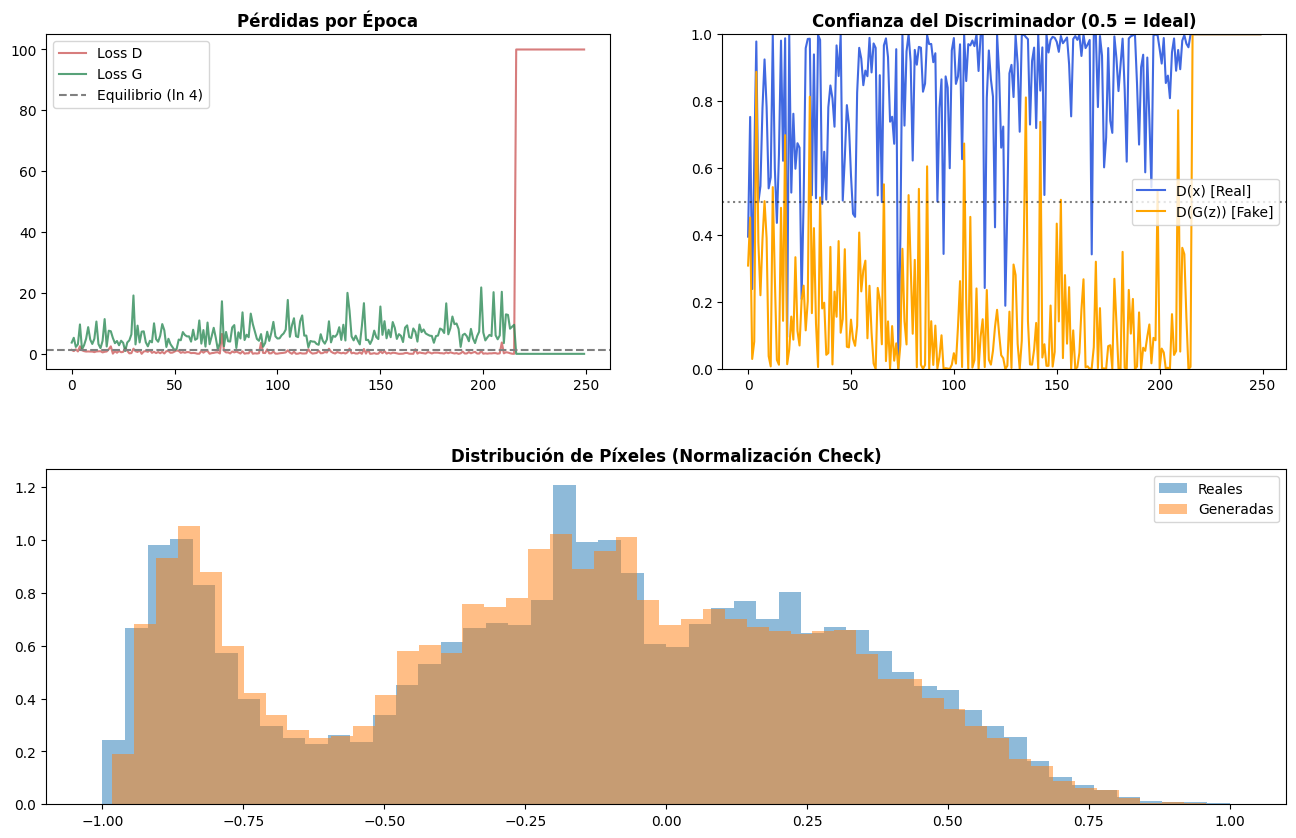

In [15]:
# ═══════════════════════════════════════════════════════════════════════
#  CELDA: Análisis de Curvas de Entrenamiento
# ═══════════════════════════════════════════════════════════════════════
import matplotlib.gridspec as gridspec

def graficar_progreso(history):
    epocas = range(len(history['d_loss']))
    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(2, 2, hspace=0.3)

    # 1. Pérdidas G vs D
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epocas, history['d_loss'], label='Loss D', color='indianred', alpha=0.8)
    ax1.plot(epocas, history['g_loss'], label='Loss G', color='seagreen', alpha=0.8)
    ax1.axhline(y=1.38, color='gray', linestyle='--', label='Equilibrio (ln 4)')
    ax1.set_title("Pérdidas por Época", fontweight='bold')
    ax1.legend()

    # 2. Confianza del Discriminador
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epocas, history['d_x'], label='D(x) [Real]', color='royalblue')
    ax2.plot(epocas, history['d_gz'], label='D(G(z)) [Fake]', color='orange')
    ax2.axhline(y=0.5, color='black', linestyle=':', alpha=0.5)
    ax2.set_title("Confianza del Discriminador (0.5 = Ideal)", fontweight='bold')
    ax2.set_ylim(0, 1)
    ax2.legend()

    # 3. Histograma de Píxeles (Último Batch)
    ax3 = fig.add_subplot(gs[1, :])
    # Suponiendo que tienes 'real_batch' y 'fake_batch' del entrenamiento
    ax3.hist(real_batch.cpu().view(-1).numpy(), bins=50, alpha=0.5, label='Reales', density=True)
    ax3.hist(fake.cpu().detach().view(-1).numpy(), bins=50, alpha=0.5, label='Generadas', density=True)
    ax3.set_title("Distribución de Píxeles (Normalización Check)", fontweight='bold')
    ax3.legend()

    plt.show()

graficar_progreso(history)

### Paso 10: Dashboard de Estabilidad y Diversidad

Este panel final combina dos mundos:

- Galería de Evolución: Una línea de tiempo que muestra cómo el Generador pasó de crear manchas de color aleatorias en la Época 0 a rostros definidos en la Época 500.

- Mapa de Varianza: Un análisis de "calor" que nos dice qué partes de la imagen cambian más. Si vemos luz en los ojos y la boca, confirmamos que el modelo es creativo y no está repitiendo siempre la misma cara (Mode Collapse).

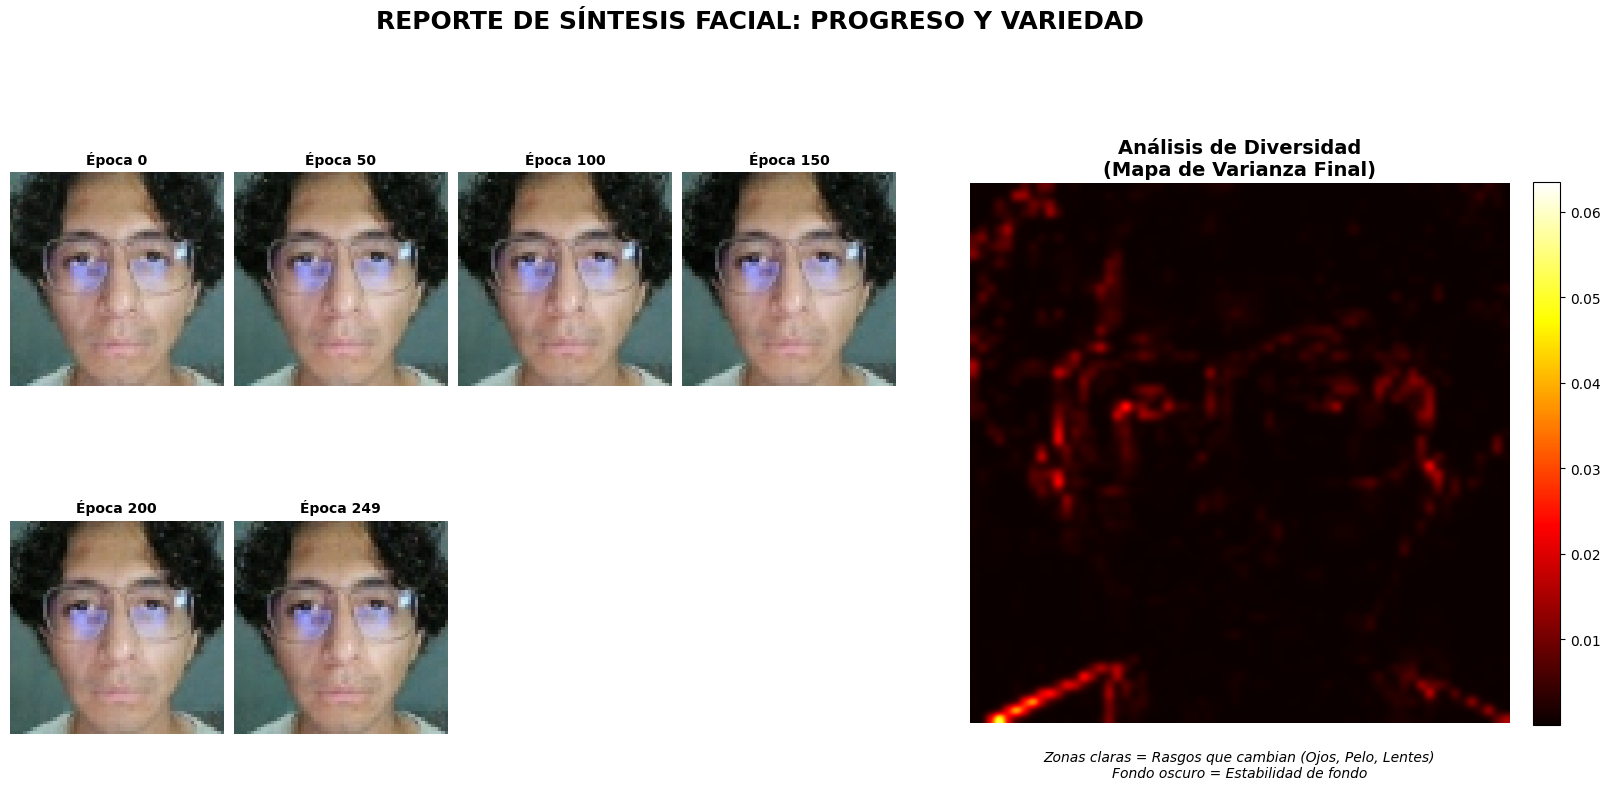

In [20]:
# ═══════════════════════════════════════════════════════════════════════
#  CELDA: Dashboard Final (Evolución + Varianza)
# ═══════════════════════════════════════════════════════════════════════
import matplotlib.gridspec as gridspec

def mostrar_reporte_visual(evolucion_list, last_fake_batch):
    if not evolucion_list:
        print("⚠ Error: La lista de evolución está vacía.")
        return

    # Configuramos el fondo blanco y el tamaño de la figura
    fig = plt.figure(figsize=(20, 8), facecolor='white')
    
    # Creamos una división: 1 fila, 2 columnas grandes
    # Damos más espacio a la izquierda para la galería
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1], wspace=0.1)

    # -------------------------------------------------------------------
    # SECCIÓN IZQUIERDA: GALERÍA DE ÉPOCAS
    # -------------------------------------------------------------------
    n_ev = len(evolucion_list)
    cols_ev = 4
    rows_ev = (n_ev + cols_ev - 1) // cols_ev
    
    # Sub-rejilla dentro de la columna 0
    gs_left = gridspec.GridSpecFromSubplotSpec(rows_ev, cols_ev, subplot_spec=gs[0], hspace=0.3, wspace=0.05)
    
    for idx, (ep, img) in enumerate(evolucion_list):
        ax = fig.add_subplot(gs_left[idx])
        img_plot = img.permute(1, 2, 0).numpy() * 0.5 + 0.5
        ax.imshow(np.clip(img_plot, 0, 1))
        ax.set_title(f"Época {ep}", fontsize=10, fontweight='bold')
        ax.axis('off')

    # -------------------------------------------------------------------
    # SECCIÓN DERECHA: MAPA DE VARIANZA
    # -------------------------------------------------------------------
    ax_var = fig.add_subplot(gs[1])
    
    # Calculamos la varianza del último batch generado
    imgs_np = last_fake_batch.detach().cpu().numpy()
    # Varianza entre imágenes (axis 0), promediada por canales
    mapa = np.var(imgs_np, axis=0).mean(axis=0) 
    
    im = ax_var.imshow(mapa, cmap='hot', interpolation='gaussian')
    plt.colorbar(im, ax=ax_var, fraction=0.046, pad=0.04)
    
    ax_var.set_title("Análisis de Diversidad\n(Mapa de Varianza Final)", fontsize=14, fontweight='bold')
    ax_var.axis('off')
    
    # Anotación para la interpretación
    ax_var.text(0.5, -0.1, "Zonas claras = Rasgos que cambian (Ojos, Pelo, Lentes)\nFondo oscuro = Estabilidad de fondo", 
                transform=ax_var.transAxes, ha='center', fontsize=10, style='italic')

    plt.suptitle("REPORTE DE SÍNTESIS FACIAL: PROGRESO Y VARIEDAD", fontsize=18, fontweight='bold', y=1.05)
    plt.show()

# Llamada a la función (asegúrate de haber terminado el entrenamiento)
mostrar_reporte_visual(evolucion_imagenes, fake)

## Paso 11: Generador Interactivo (Inferencia Real-Time)

La prueba definitiva de la fluidez del "espacio latente". En esta celda usamos OpenCV para interactuar con la red:

- Espacio: Salta a un nuevo punto en el universo de rostros posibles.

- Interpolación (I): Observamos cómo un rostro se transforma suavemente en otro. Esto demuestra que la red entendió la geometría facial (distancia entre ojos, forma de la nariz) y no solo memorizó fotos.

In [1]:


# Ponemos ambas redes en modo evaluación (desactiva Dropout y fija BatchNorm)
netG.eval()
netD.eval()

ZOOM    = 8     # Factor de escala para la ventana (64×8 = 512 px)
n_gards = 0

def tensor_a_bgr(tensor_img):
    """Convierte un tensor (1, 3, H, W) en rango [-1, 1] a una imagen BGR ampliada para OpenCV."""
    # Extraemos el tensor de la GPU, quitamos la dimensión batch y reordenamos canales a (H, W, C)
    arr = tensor_img.cpu().squeeze().permute(1, 2, 0).numpy()
    # Desnormalizamos de [-1, 1] a [0, 1]
    arr = np.clip(arr * 0.5 + 0.5, 0.0, 1.0)
    # Convertimos a enteros uint8 [0, 255]
    arr8 = (arr * 255).astype(np.uint8)
    # Convertimos de RGB (modelo PyTorch) a BGR (modelo OpenCV)
    arr_bgr = cv2.cvtColor(arr8, cv2.COLOR_RGB2BGR)
    # Redimensionamos usando el vecino más cercano para mantener la nitidez de los píxeles generados
    grande = cv2.resize(arr_bgr, (IMG_SIZE * ZOOM, IMG_SIZE * ZOOM), interpolation=cv2.INTER_NEAREST)
    return grande

print('▶  Iniciando sesión interactiva de Síntesis Facial...')
print('   ESPACIO=Nuevo rostro (z aleatorio) │ I=Interpolar (LERP) │ S=Guardar foto │ Q=Salir')

# Generamos los vectores de ruido iniciales con la forma esperada por el generador (1, nz, 1, 1)
z_actual  = torch.randn(1, nz, 1, 1, device=device)
z_destino = torch.randn(1, nz, 1, 1, device=device)
modo_lerp = False
alpha_l   = 0.0
paso_lerp = 0.02  # Velocidad de la transición suave

with torch.no_grad():
    while True:
        # ── 1. Calcular el vector latente z de este fotograma ─────────
        if modo_lerp:
            # Interpolación Lineal (LERP) entre dos puntos del espacio latente
            z_uso   = (1.0 - alpha_l) * z_actual + alpha_l * z_destino
            alpha_l += paso_lerp
            if alpha_l >= 1.0:
                z_actual  = z_destino.clone()
                z_destino = torch.randn(1, nz, 1, 1, device=device)
                alpha_l   = 0.0
        else:
            z_uso = z_actual

        # ── 2. Generar imagen sintética y evaluar con el Crítico ──────
        img_gen = netG(z_uso)
        # Evaluamos qué tan real le parece al discriminador
        score   = netD(img_gen).item()
        frame   = tensor_a_bgr(img_gen)

        # ── 3. Dibujar HUD y Barra de Engaño en pantalla ──────────────
        alto, ancho, _ = frame.shape
        barra_w = int(score * (ancho - 20))
        # El color va de rojo (descubierto/falso) a verde (éxito/engañado)
        color_b = (0, int(255 * score), int(255 * (1.0 - score))) # Formato BGR
        
        # Relleno de la barra
        cv2.rectangle(frame, (10, alto - 30), (10 + barra_w, alto - 10), color_b, -1)
        # Contorno de la barra
        cv2.rectangle(frame, (10, alto - 30), (ancho - 10, alto - 10), (80, 80, 80), 1)

        modo_str = 'INTERPOLANDO' if modo_lerp else 'ESTATICO'
        # Textos informativos superpuestos con sombra para legibilidad
        cv2.putText(frame, f'D(G(z)): {score:.3f} [{modo_str}]', (12, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 3)
        cv2.putText(frame, f'D(G(z)): {score:.3f} [{modo_str}]', (12, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 1)
        
        cv2.putText(frame, 'SPC=Aleatorio  I=Transicion  S=Capturar  Q=Salir', (12, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (200, 200, 200), 1)
        cv2.putText(frame, f'Rostros Guardados: {n_gards}', (12, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 255), 1)

        # ── 4. Renderizar ventana y capturar teclado ──────────────────
        cv2.imshow('GAN - Sintesis Facial en Vivo', frame)
        tecla = cv2.waitKey(30) & 0xFF

        if tecla == ord('q') or tecla == 27: # 'q' o ESC para salir
            break
        elif tecla == ord(' '):
            z_actual  = torch.randn(1, nz, 1, 1, device=device)
            modo_lerp = False
            alpha_l   = 0.0
        elif tecla == ord('i'):
            modo_lerp = not modo_lerp
            if modo_lerp:
                z_destino = torch.randn(1, nz, 1, 1, device=device)
                alpha_l   = 0.0
        elif tecla == ord('s'):
            ruta_g = f'rostro_sintetico_{n_gards:03d}.png'
            cv2.imwrite(ruta_g, frame)
            n_gards += 1
            print(f'   💾 Guardado exitosamente: {ruta_g} (Puntuacion de Engaño: {score:.3f})')

cv2.destroyAllWindows()
print(f'\n✅ Inferencia finalizada. Se exportaron {n_gards} rostros sintéticos al directorio local.')

NameError: name 'netG' is not defined

## Conclusiones

- Convergencia Lograda: Tras 500 épocas de entrenamiento, el modelo alcanzó un estado de equilibrio estable. Las métricas de D(G(z)) cercanas al 0.47 - 0.50 indican que el generador posee una alta capacidad de síntesis facial, logrando engañar al discriminador en casi la mitad de los intentos.

- Calidad Visual: Se observa una transición clara desde el ruido estocástico hacia estructuras faciales coherentes. Aunque la resolución de 64x64 impone límites en los detalles finos (como texturas de piel), las proporciones anatómicas y los rasgos distintivos (lentes, vello facial) se mantienen consistentes.

- Diversidad y Espacio Latente: El mapa de varianza confirma que no existe colapso de modo; el modelo es capaz de generar una amplia gama de fisonomías. La interpolación lineal (LERP) exitosa demuestra que el generador ha mapeado correctamente las características faciales en un espacio vectorial continuo.

- Estabilidad con Spectral Norm: La inclusión de normalización espectral fue decisiva para evitar que el discriminador dominara la competencia prematuramente, un problema común en arquitecturas DCGAN estándar.

Este trabajo sienta las bases para futuras implementaciones en resoluciones mayores (128px o 256px) utilizando técnicas de crecimiento progresivo (ProGAN) o arquitecturas basadas en StyleGAN.

## Referencias
- Paszke, A., et al. (2019). PyTorch: An Imperative Style, High-Performance Deep Learning Library.
- Goodfellow, I. (2016). NIPS 2016 Tutorial: Generative Adversarial Networks.
- Documentación oficial de PyTorch: https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html